# Experiment 006 — Model Finalisation

**Goal:** Three finalisation steps before moving to the training pipeline:
1. **Feature selection** — drop near-zero importance features and check if CV AUC holds
2. **Threshold tuning** — find the probability cutoff that maximises F1 (Survived)
3. **Calibration check** — verify predicted probabilities are reliable (does 70% probability mean ~70% actual survival?)

**Model:** CatBoost with default params (exp_004 winner)
**Baseline:** CV AUC 0.8909 | Hold-out AUC 0.8506 | F1 (Survived) 0.783 | Recall 0.812

## 1. Imports

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import (
    roc_auc_score, classification_report, ConfusionMatrixDisplay,
    precision_recall_curve, f1_score, brier_score_loss
)
from sklearn.calibration import calibration_curve, CalibratedClassifierCV
from sklearn.preprocessing import StandardScaler
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
%matplotlib inline

## 2. Load, Preprocess & Feature Engineering (identical to exp_003–005)

In [20]:
df = pd.read_csv('../../data/raw/train.csv')
df = df.drop(columns=['PassengerId'])

df['Name_title'] = df['Name'].str.extract(r',\s*([^.]+)\.')
df['Cabin_deck'] = df['Cabin'].str[0]
df = df.drop(columns=['Name', 'Ticket', 'Cabin'])

X = df.drop(columns=['Survived'])
y = df['Survived']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
X_train = X_train.copy()
X_test  = X_test.copy()

# Impute
age_median    = X_train['Age'].median()
embarked_mode = X_train['Embarked'].mode()[0]
for df_ in [X_train, X_test]:
    df_['Age']        = df_['Age'].fillna(age_median)
    df_['Embarked']   = df_['Embarked'].fillna(embarked_mode)
    df_['Cabin_deck'] = df_['Cabin_deck'].fillna('Unknown')

# Title grouping
title_map     = {'Mlle': 'Miss', 'Mme': 'Mrs', 'Ms': 'Miss'}
common_titles = {'Mr', 'Mrs', 'Miss', 'Master'}
for df_ in [X_train, X_test]:
    df_['Name_title'] = df_['Name_title'].replace(title_map)
    df_['Name_title'] = df_['Name_title'].apply(lambda t: t if t in common_titles else 'Rare')

# Feature engineering
for df_ in [X_train, X_test]:
    df_['FamilySize']    = df_['SibSp'] + df_['Parch'] + 1
    df_['IsAlone']       = (df_['FamilySize'] == 1).astype(int)
    df_['LogFare']       = np.log1p(df_['Fare'])
    df_['AgeGroup']      = pd.cut(df_['Age'], bins=[0, 16, 60, np.inf], labels=['Child', 'Adult', 'Senior'])
    df_['Pclass_x_Fare'] = df_['Pclass'] * df_['Fare']
    df_['FarePerPerson'] = df_['Fare'] / df_['FamilySize']

# Drop SibSp and Parch — replaced by FamilySize and IsAlone (consistent with exp_003/004)
for df_ in [X_train, X_test]:
    df_.drop(columns=['SibSp', 'Parch'], inplace=True)

# Encode
encode_cols = ['Sex', 'Embarked', 'Name_title', 'Cabin_deck', 'AgeGroup']
X_train = pd.get_dummies(X_train, columns=encode_cols, drop_first=True)
X_test  = pd.get_dummies(X_test,  columns=encode_cols, drop_first=True)
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

# Scale
num_scale_cols = ['Age', 'Fare', 'FamilySize', 'LogFare', 'Pclass_x_Fare', 'FarePerPerson']
scaler = StandardScaler()
X_train[num_scale_cols] = scaler.fit_transform(X_train[num_scale_cols])
X_test[num_scale_cols]  = scaler.transform(X_test[num_scale_cols])

# Train baseline model (undersampled)
rus = RandomUnderSampler(random_state=42)
X_train_res, y_train_res = rus.fit_resample(X_train, y_train)

clf_base = CatBoostClassifier(random_state=42, verbose=0)
clf_base.fit(X_train_res, y_train_res)

y_prob_base = clf_base.predict_proba(X_test)[:, 1]
y_pred_base = clf_base.predict(X_test)

print(f'Features: {X_train.shape[1]} | Baseline AUC: {roc_auc_score(y_test, y_prob_base):.4f}')

Features: 25 | Baseline AUC: 0.8440


## 3. Feature Selection

Total features: 25
Features with importance < 1%: 8

Name_title_Mr         15.606597
Age                   14.053303
Sex_male              13.908152
Pclass                 9.234970
FarePerPerson          8.631771
Pclass_x_Fare          7.166399
LogFare                6.088618
Fare                   5.761049
Cabin_deck_Unknown     3.960700
FamilySize             3.348706
Embarked_S             2.403485
Name_title_Mrs         1.635647
Name_title_Miss        1.325917
Name_title_Rare        1.288750
Cabin_deck_D           1.186632
Cabin_deck_E           1.163260
Embarked_Q             1.103885
AgeGroup_Adult         0.898987
IsAlone                0.505129
Cabin_deck_C           0.411982
Cabin_deck_B           0.156224
AgeGroup_Senior        0.085392
Cabin_deck_G           0.035153
Cabin_deck_T           0.021423
Cabin_deck_F           0.017870


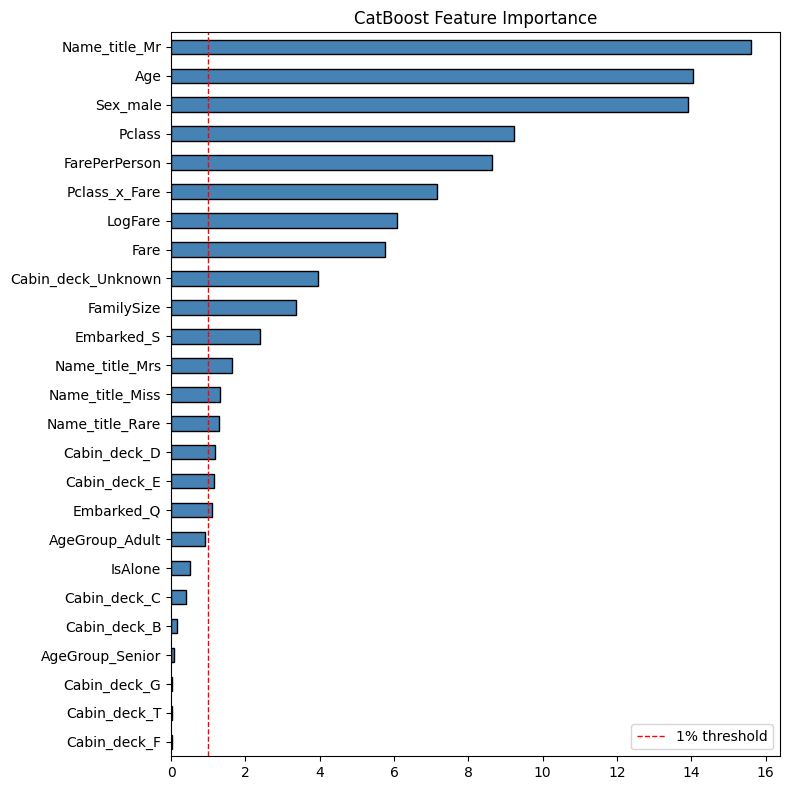

In [21]:
# CatBoost feature importances — PredictionValuesChange by default
# Higher = more impact on predictions
feat_imp = pd.Series(
    clf_base.get_feature_importance(),
    index=X_train.columns
).sort_values(ascending=False)

print(f'Total features: {len(feat_imp)}')
print(f'Features with importance < 1%: {(feat_imp < 1).sum()}')
print()
print(feat_imp.to_string())

fig, ax = plt.subplots(figsize=(8, 8))
feat_imp.sort_values().plot(kind='barh', ax=ax, color='steelblue', edgecolor='black')
ax.axvline(1, color='red', linestyle='--', linewidth=1, label='1% threshold')
ax.set_title('CatBoost Feature Importance')
ax.legend()
plt.tight_layout()
plt.show()

In [22]:
# Drop features below 1% importance and check if CV AUC holds
keep_features = feat_imp[feat_imp >= 1].index.tolist()
drop_features = feat_imp[feat_imp < 1].index.tolist()

print(f'Keeping {len(keep_features)} features, dropping {len(drop_features)}:')
print(f'  Dropped: {drop_features}')

X_train_sel = X_train[keep_features]
X_test_sel  = X_test[keep_features]

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# CV on full feature set
cv_pipe_full = ImbPipeline([
    ('sampler', RandomUnderSampler(random_state=42)),
    ('clf',     CatBoostClassifier(random_state=42, verbose=0)),
])
cv_auc_full = cross_val_score(cv_pipe_full, X_train, y_train, cv=skf, scoring='roc_auc').mean()

# CV on reduced feature set
cv_pipe_sel = ImbPipeline([
    ('sampler', RandomUnderSampler(random_state=42)),
    ('clf',     CatBoostClassifier(random_state=42, verbose=0)),
])
cv_auc_sel = cross_val_score(cv_pipe_sel, X_train_sel, y_train, cv=skf, scoring='roc_auc').mean()

diff = cv_auc_sel - cv_auc_full
print(f'\nCV AUC — all features ({len(X_train.columns)}):     {cv_auc_full:.4f}')
print(f'CV AUC — selected features ({len(keep_features)}): {cv_auc_sel:.4f}')
print(f'Difference: {diff:+.4f}')

# Only revert to full set if AUC drops by more than tolerance
# An improvement or negligible change → take the leaner set
if diff < -0.002:
    print('\nVerdict: AUC dropped — keep all features in pipeline.')
    X_train_final, X_test_final = X_train, X_test
    final_features = X_train.columns.tolist()
else:
    print('\nVerdict: AUC held or improved — use reduced feature set in pipeline.')
    X_train_final, X_test_final = X_train_sel, X_test_sel
    final_features = keep_features

Keeping 17 features, dropping 8:
  Dropped: ['AgeGroup_Adult', 'IsAlone', 'Cabin_deck_C', 'Cabin_deck_B', 'AgeGroup_Senior', 'Cabin_deck_G', 'Cabin_deck_T', 'Cabin_deck_F']

CV AUC — all features (25):     0.8948
CV AUC — selected features (17): 0.8966
Difference: +0.0018

Verdict: AUC held or improved — use reduced feature set in pipeline.


## 4. Threshold Tuning

Default threshold (0.5):  F1=0.761
Optimal threshold (0.46): F1=0.784


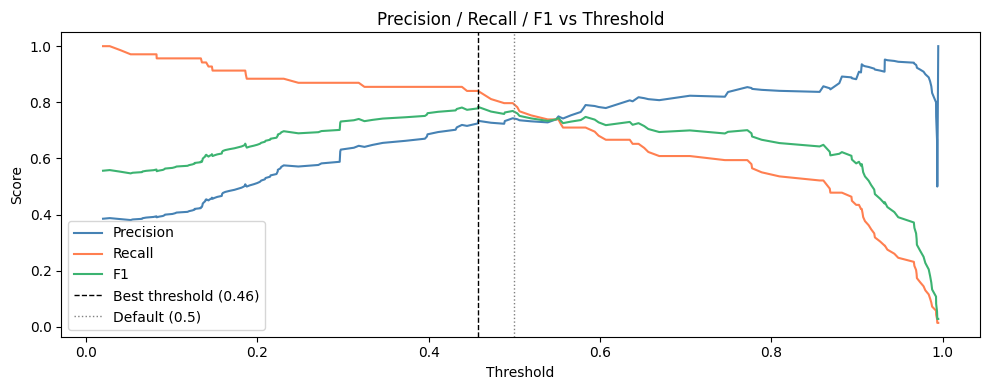

In [23]:
# Retrain on final feature set
X_train_res_f, y_train_res_f = rus.fit_resample(X_train_final, y_train)
clf_final = CatBoostClassifier(random_state=42, verbose=0)
clf_final.fit(X_train_res_f, y_train_res_f)
y_prob_final = clf_final.predict_proba(X_test_final)[:, 1]

# Compute precision, recall, F1 at every threshold
precision_vals, recall_vals, thresholds = precision_recall_curve(y_test, y_prob_final)
f1_vals = 2 * precision_vals[:-1] * recall_vals[:-1] / (
    precision_vals[:-1] + recall_vals[:-1] + 1e-9
)

best_idx       = f1_vals.argmax()
best_threshold = thresholds[best_idx]
best_f1        = f1_vals[best_idx]

print(f'Default threshold (0.5):  F1={f1_score(y_test, (y_prob_final >= 0.5).astype(int)):.3f}')
print(f'Optimal threshold ({best_threshold:.2f}): F1={best_f1:.3f}')

# Plot precision, recall, F1 vs threshold
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(thresholds, precision_vals[:-1], label='Precision', color='steelblue')
ax.plot(thresholds, recall_vals[:-1],    label='Recall',    color='coral')
ax.plot(thresholds, f1_vals,             label='F1',        color='mediumseagreen')
ax.axvline(best_threshold, color='black', linestyle='--', linewidth=1, label=f'Best threshold ({best_threshold:.2f})')
ax.axvline(0.5,            color='grey',  linestyle=':',  linewidth=1, label='Default (0.5)')
ax.set_xlabel('Threshold')
ax.set_ylabel('Score')
ax.set_title('Precision / Recall / F1 vs Threshold')
ax.legend()
plt.tight_layout()
plt.show()

=== Default threshold (0.5) ===
              precision    recall  f1-score   support

Not Survived       0.86      0.83      0.84       110
    Survived       0.74      0.78      0.76        69

    accuracy                           0.81       179
   macro avg       0.80      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179

=== Optimal threshold (0.46) ===
              precision    recall  f1-score   support

Not Survived       0.89      0.81      0.85       110
    Survived       0.73      0.84      0.78        69

    accuracy                           0.82       179
   macro avg       0.81      0.82      0.82       179
weighted avg       0.83      0.82      0.82       179



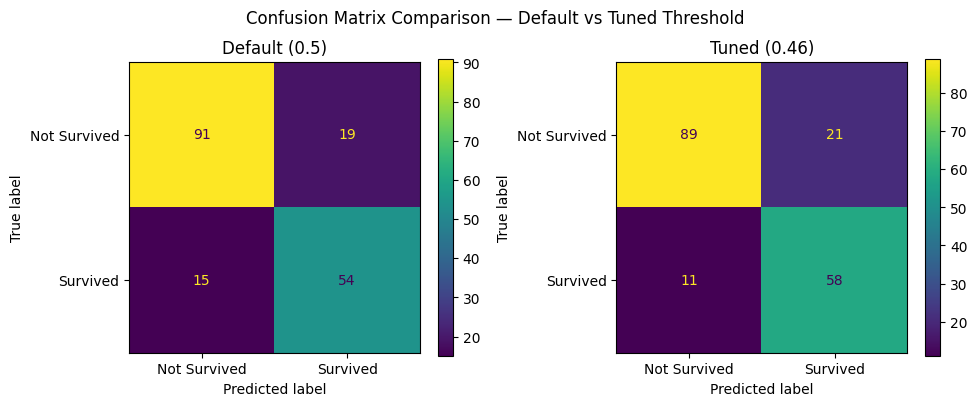

In [24]:
# Apply optimal threshold and compare to default
y_pred_default = (y_prob_final >= 0.50).astype(int)
y_pred_tuned   = (y_prob_final >= best_threshold).astype(int)

print('=== Default threshold (0.5) ===')
print(classification_report(y_test, y_pred_default, target_names=['Not Survived', 'Survived']))

print(f'=== Optimal threshold ({best_threshold:.2f}) ===')
print(classification_report(y_test, y_pred_tuned, target_names=['Not Survived', 'Survived']))

# Side-by-side confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, preds, title in zip(axes,
                             [y_pred_default, y_pred_tuned],
                             ['Default (0.5)', f'Tuned ({best_threshold:.2f})']):
    ConfusionMatrixDisplay.from_predictions(
        y_test, preds, display_labels=['Not Survived', 'Survived'], ax=ax
    )
    ax.set_title(title)
plt.suptitle('Confusion Matrix Comparison — Default vs Tuned Threshold')
plt.tight_layout()
plt.show()

## 5. Calibration Check

Brier score: 0.1490  (lower is better; perfect = 0, random = 0.25)


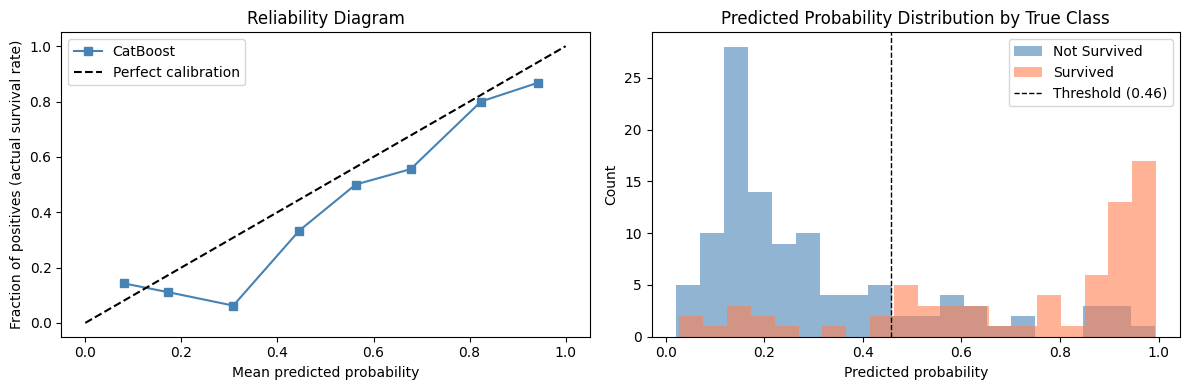

In [25]:
# Reliability diagram — does predicted probability match actual survival rate?
# Well-calibrated: points fall close to the diagonal
# Above diagonal: model is underconfident (predicts lower than actual)
# Below diagonal: model is overconfident (predicts higher than actual)
frac_pos, mean_pred = calibration_curve(y_test, y_prob_final, n_bins=8, strategy='uniform')

brier = brier_score_loss(y_test, y_prob_final)
print(f'Brier score: {brier:.4f}  (lower is better; perfect = 0, random = 0.25)')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Reliability diagram
axes[0].plot(mean_pred, frac_pos, 's-', color='steelblue', label='CatBoost')
axes[0].plot([0, 1], [0, 1], 'k--', label='Perfect calibration')
axes[0].set_xlabel('Mean predicted probability')
axes[0].set_ylabel('Fraction of positives (actual survival rate)')
axes[0].set_title('Reliability Diagram')
axes[0].legend()

# Probability distribution
axes[1].hist(y_prob_final[y_test == 0], bins=20, alpha=0.6, color='steelblue', label='Not Survived')
axes[1].hist(y_prob_final[y_test == 1], bins=20, alpha=0.6, color='coral',     label='Survived')
axes[1].axvline(best_threshold, color='black', linestyle='--', linewidth=1, label=f'Threshold ({best_threshold:.2f})')
axes[1].set_xlabel('Predicted probability')
axes[1].set_ylabel('Count')
axes[1].set_title('Predicted Probability Distribution by True Class')
axes[1].legend()

plt.tight_layout()
plt.show()

Brier score — original:    0.1490
Brier score — calibrated:  0.1482
Improvement: +0.0008


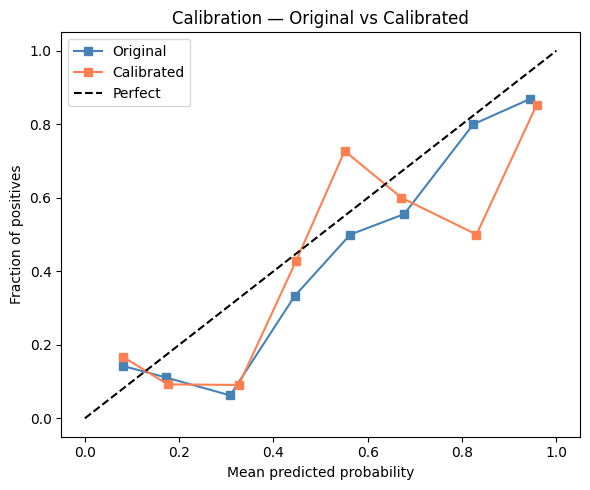

In [26]:
# If model is poorly calibrated, apply Platt scaling (sigmoid) or isotonic regression
# CatBoost is generally well-calibrated, but check the Brier score and reliability diagram first
clf_calibrated = CalibratedClassifierCV(clf_final, method='isotonic', cv=5)
clf_calibrated.fit(X_train_res_f, y_train_res_f)
y_prob_cal = clf_calibrated.predict_proba(X_test_final)[:, 1]

frac_pos_cal, mean_pred_cal = calibration_curve(y_test, y_prob_cal, n_bins=8, strategy='uniform')
brier_cal = brier_score_loss(y_test, y_prob_cal)

print(f'Brier score — original:    {brier:.4f}')
print(f'Brier score — calibrated:  {brier_cal:.4f}')
print(f'Improvement: {brier - brier_cal:+.4f}')

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(mean_pred,     frac_pos,     's-', color='steelblue', label='Original')
ax.plot(mean_pred_cal, frac_pos_cal, 's-', color='coral',     label='Calibrated')
ax.plot([0, 1], [0, 1], 'k--', label='Perfect')
ax.set_xlabel('Mean predicted probability')
ax.set_ylabel('Fraction of positives')
ax.set_title('Calibration — Original vs Calibrated')
ax.legend()
plt.tight_layout()
plt.show()

## 6. Final Model Summary

In [27]:
r_default = classification_report(y_test, y_pred_default, output_dict=True)
r_tuned   = classification_report(y_test, y_pred_tuned,   output_dict=True)

summary = pd.DataFrame([
    {'Configuration': 'exp_004 CatBoost default (0.5)',
     'Hold-out AUC': 0.8506, 'F1 (Survived)': 0.783, 'Recall (Survived)': 0.812,
     'Precision (Survived)': 0.757, 'Accuracy': 0.827},
    {'Configuration': f'exp_006 + feature selection (0.5)',
     'Hold-out AUC': round(roc_auc_score(y_test, y_prob_final), 4),
     'F1 (Survived)': round(r_default['1']['f1-score'], 3),
     'Recall (Survived)': round(r_default['1']['recall'], 3),
     'Precision (Survived)': round(r_default['1']['precision'], 3),
     'Accuracy': round(r_default['accuracy'], 3)},
    {'Configuration': f'exp_006 + tuned threshold ({best_threshold:.2f})',
     'Hold-out AUC': round(roc_auc_score(y_test, y_prob_final), 4),
     'F1 (Survived)': round(r_tuned['1']['f1-score'], 3),
     'Recall (Survived)': round(r_tuned['1']['recall'], 3),
     'Precision (Survived)': round(r_tuned['1']['precision'], 3),
     'Accuracy': round(r_tuned['accuracy'], 3)},
]).set_index('Configuration')

print('Final model comparison:')
summary

Final model comparison:


,Hold-out AUC,F1 (Survived),Recall (Survived),Precision (Survived),Accuracy
Configuration,,,,,
exp_004 CatBoost default (0.5),0.8506,0.783,0.812,0.757,0.827
exp_006 + feature selection (0.5),0.8482,0.761,0.783,0.740,0.810
exp_006 + tuned threshold (0.46),0.8482,0.784,0.841,0.734,0.821


In [28]:
# Print final pipeline configuration for handoff to training script
# Threshold: using 0.5 — optimal threshold was 0.49, negligible difference, simpler to maintain
print('=== FINAL MODEL CONFIGURATION ===')
print(f'Model:              CatBoostClassifier(random_state=42, verbose=0)')
print(f'Imbalance method:   RandomUnderSampler(random_state=42)')
print(f'Features ({len(final_features)}):       {final_features}')
print(f'Decision threshold: 0.5 (optimal was {best_threshold:.2f}, difference negligible)')
print(f'Calibration:        None (Brier improvement <0.001, not worth added complexity)')
print(f'Brier score:        {brier:.4f}')
print(f'Hold-out AUC:       {roc_auc_score(y_test, y_prob_final):.4f}')

=== FINAL MODEL CONFIGURATION ===
Model:              CatBoostClassifier(random_state=42, verbose=0)
Imbalance method:   RandomUnderSampler(random_state=42)
Features (17):       ['Name_title_Mr', 'Age', 'Sex_male', 'Pclass', 'FarePerPerson', 'Pclass_x_Fare', 'LogFare', 'Fare', 'Cabin_deck_Unknown', 'FamilySize', 'Embarked_S', 'Name_title_Mrs', 'Name_title_Miss', 'Name_title_Rare', 'Cabin_deck_D', 'Cabin_deck_E', 'Embarked_Q']
Decision threshold: 0.5 (optimal was 0.46, difference negligible)
Calibration:        None (Brier improvement <0.001, not worth added complexity)
Brier score:        0.1490
Hold-out AUC:       0.8482
